# **DV - Optimizing IT Support Team Performance Using Analytics ( Supportlytics)**
## **Project Overview**
This project analyzes Customer Support Tickets data to uncover insights about:

- Understand and preprocess IT support ticket data for analysis.

- Explore trends in ticket volume, priority, resolution time, and category distribution.

- Identify clusters of similar issues using similarity scores and clustering techniques

- Visualize performance metrics through charts.



### **Importing Libraries**

In [ ]:
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Loading Dataset**

In [ ]:
# loading Dataset
df=pd.read_excel('customer_support_tickets.xlsx')
df

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Unnamed: 9,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,NaN,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,NaN,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,NaN,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,NaN,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,NaN,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,NaN,Open,NaN,Low,Phone,NaT,NaT,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,NaN,Open,NaN,Critical,Email,NaT,NaT,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,NaN,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,NaN,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0


### **Basic Functions for Data Analysis**

In [ ]:
# To display first 5 rows
df.head(5)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Unnamed: 9,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,NaN,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,NaN,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,NaN,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,NaN,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,NaN,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [ ]:
# To display last 5 rows
df.tail(5)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Unnamed: 9,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,NaN,Open,NaN,Low,Phone,NaT,NaT,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,NaN,Open,NaN,Critical,Email,NaT,NaT,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,NaN,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,NaN,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0
8468,8469,Steven Davis MD,lori20@example.net,53,Other,Philips Hue Lights,2020-06-01,Billing inquiry,Hardware issue,NaN,Open,NaN,High,Phone,NaT,NaT,NaN


In [ ]:
# To get random samples from dataset
df.sample(10)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Unnamed: 9,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
6438,6439,Jason Sharp,griffinpaula@example.org,24,Female,Garmin Forerunner,2020-12-26,Cancellation request,Delivery problem,NaN,Open,NaN,Low,Chat,NaT,NaT,NaN
4991,4992,Joshua Little,nvasquez@example.com,46,Other,LG Washing Machine,2020-01-03,Refund request,Display issue,NaN,Pending Customer Response,NaN,High,Social media,2023-06-01 04:42:13,NaT,NaN
3855,3856,Daniel Hoffman,beasleyadam@example.net,42,Other,Sony Xperia,2021-04-23,Refund request,Hardware issue,NaN,Open,NaN,Critical,Chat,NaT,NaT,NaN
2220,2221,Jonathan Murphy,peckvalerie@example.org,64,Other,GoPro Hero,2020-01-19,Cancellation request,Product compatibility,NaN,Open,NaN,Low,Email,NaT,NaT,NaN
6006,6007,Sara Torres,ddean@example.org,38,Female,Microsoft Surface,2021-12-01,Product inquiry,Peripheral compatibility,NaN,Pending Customer Response,NaN,Medium,Chat,2023-06-01 11:10:36,NaT,NaN
442,443,Carlos Ochoa,hcarter@example.com,66,Other,Bose QuietComfort,2020-03-26,Refund request,Software bug,NaN,Pending Customer Response,NaN,Low,Chat,2023-06-01 00:58:44,NaT,NaN
1099,1100,Brenda Deleon,crystaljones@example.net,20,Other,Philips Hue Lights,2021-07-04,Refund request,Data loss,NaN,Open,NaN,Medium,Phone,NaT,NaT,NaN
3682,3683,Michael Sharp,csuarez@example.net,35,Female,GoPro Hero,2021-10-28,Product inquiry,Cancellation request,NaN,Pending Customer Response,NaN,High,Email,2023-06-01 02:20:17,NaT,NaN
7503,7504,Tammy Scott,adamsjoseph@example.net,44,Male,Canon DSLR Camera,2021-10-08,Product inquiry,Software bug,NaN,Closed,Visit prove list themselves democratic TV say.,Low,Chat,2023-06-01 23:32:06,2023-06-01 18:22:06,3.0
4872,4873,John Davis,michaelzamora@example.org,34,Other,Nikon D,2020-11-27,Technical issue,Peripheral compatibility,NaN,Pending Customer Response,NaN,Critical,Email,2023-06-01 00:05:32,NaT,NaN


In [ ]:
# to display total number of Rows and Columns
df.shape

(8469, 17)

In [ ]:
# to display data type of colunms in dataset
df.dtypes

,0
Ticket ID,int64
Customer Name,object
Customer Email,object
Customer Age,int64
Customer Gender,object
Product Purchased,object
Date of Purchase,datetime64[ns]
Ticket Type,object
Ticket Subject,object
Unnamed: 9,float64


In [ ]:
# To display information of the Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   object        
 2   Customer Email                8469 non-null   object        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   object        
 5   Product Purchased             8469 non-null   object        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   object        
 8   Ticket Subject                8469 non-null   object        
 9   Unnamed: 9                    0 non-null      float64       
 10  Ticket Status                 8469 non-null   object        
 11  Resolution                    

In [ ]:
# To display descriptive statistics for numeric columns
df.describe()

,Ticket ID,Customer Age,Date of Purchase,Unnamed: 9,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469.000000,8469,0.0,5650,2769,2769.000000
mean,4235.000000,44.026804,2020-12-30 01:35:13.071201024,NaN,2023-06-01 11:26:47.270265600,2023-06-01 11:17:21.509931520,2.991333
min,1.000000,18.000000,2020-01-01 00:00:00,NaN,2023-05-31 21:55:39,2023-05-31 21:53:30,1.000000
25%,2118.000000,31.000000,2020-07-02 00:00:00,NaN,2023-06-01 05:24:28.750000128,2023-06-01 05:34:43,2.000000
50%,4235.000000,44.000000,2020-12-31 00:00:00,NaN,2023-06-01 11:26:25,2023-06-01 11:17:48,3.000000
75%,6352.000000,57.000000,2021-07-01 00:00:00,NaN,2023-06-01 17:37:06.249999872,2023-06-01 17:07:32,4.000000
max,8469.000000,70.000000,2021-12-30 00:00:00,NaN,2023-06-02 00:54:21,2023-06-02 00:55:33,5.000000
std,2444.934048,15.296112,NaN,NaN,NaN,NaN,1.407016


In [ ]:
# To display Column names
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Unnamed: 9', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [ ]:
# To check for Null values
print(df.isnull().sum())

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Unnamed: 9                      8469
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


In [ ]:
# To count unique values in a column
df['Ticket Type'].value_counts()

,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


In [ ]:
# To count unique values in a column
df['Ticket Priority'].value_counts()

,count
Ticket Priority,
Medium,2192
Critical,2129
High,2085
Low,2063


In [ ]:
# To count unique values in a column
df['Ticket Channel'].value_counts()

,count
Ticket Channel,
Email,2143
Phone,2132
Social media,2121
Chat,2073


In [ ]:
# To count unique values in a column
df['Customer Gender'].value_counts()

,count
Customer Gender,
Male,2896
Female,2887
Other,2686


### **Data Cleaning**

#### 1.Handle Missing Values:

In [ ]:
# Fill Customer Satisfaction Rating with zero
df["Customer Satisfaction Rating"] = df["Customer Satisfaction Rating"].fillna(0)



#### 2. Convert Data Type:

In [ ]:
# Convert 'Customer Satisfaction Rating' to int
df["Customer Satisfaction Rating"] = df["Customer Satisfaction Rating"].astype(int)

#### 3. Remove column:

In [ ]:
# Removing multiple columns
df = df.drop(["Unnamed: 9", "Resolution", "Customer Email"], axis=1)


### **Feature Engineering**

In [ ]:
priority_mapping = {"Low": 1,"Medium": 2,"High": 3,"Critical": 4}
df["Priority_Score"] = df["Ticket Priority"].map(priority_mapping)

In [ ]:
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Priority_Score
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT,0,4
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT,0,4
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3,1
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3,1
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,NaT,NaT,0,1
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,NaT,NaT,0,4
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3,3
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3,2


In [ ]:
df['Resolution_Duration_Hours'] = ((df['Time to Resolution'] - df['First Response Time']) .dt.total_seconds() / 3600).abs().round(2)


In [ ]:
df['Resolution_Duration_Hours'].nunique()

1061

In [ ]:
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Priority_Score,Resolution_Duration_Hours
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT,0,4,NaN
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT,0,4,NaN
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3,1,6.85
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3,1,5.53
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1,1,19.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,NaT,NaT,0,1,NaN
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,NaT,NaT,0,4,NaN
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3,3,5.22
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3,2,12.93


In [ ]:
def categorize_time(hours):
    if hours<=4:
        return "Fast"
    elif hours<=12:
        return "Medium"
    else:
        return "Slow"

df['Resolution_category']=df['Resolution_Duration_Hours'].apply(categorize_time)
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Priority_Score,Resolution_Duration_Hours,Resolution_category
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT,0,4,NaN,Slow
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT,0,4,NaN,Slow
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3,1,6.85,Medium
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3,1,5.53,Medium
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1,1,19.68,Slow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,NaT,NaT,0,1,NaN,Slow
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,NaT,NaT,0,4,NaN,Slow
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3,3,5.22,Medium
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3,2,12.93,Slow


### **Exploratory Data Analysis**

#### 1.Distribution of Ticket Types

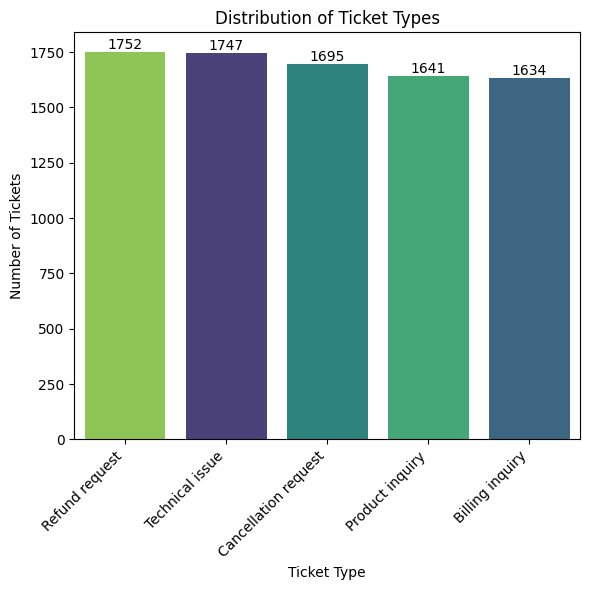

In [ ]:
plt.figure(figsize=(6, 6))
ax = sns.countplot(x='Ticket Type', data=df, order=df['Ticket Type'].value_counts().index, palette='viridis', hue='Ticket Type', legend=False)
plt.title('Distribution of Ticket Types')
plt.xlabel('Ticket Type')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.tight_layout()
plt.show()

#### 2.Distribution of Customer Gender

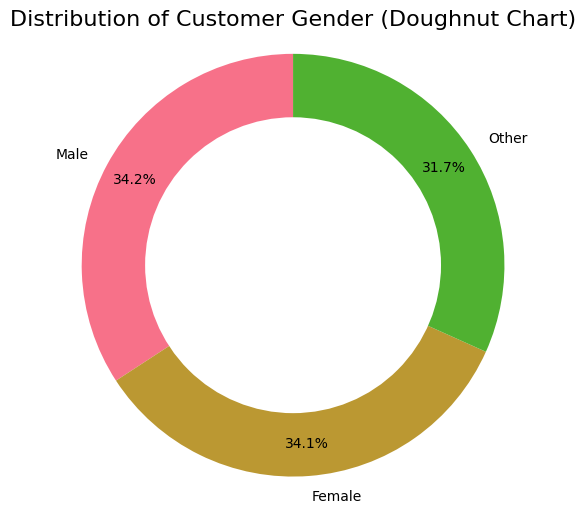

In [ ]:
gender_counts = df['Customer Gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85, colors=sns.color_palette('husl'))
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Distribution of Customer Gender (Doughnut Chart)', fontsize=16)
plt.axis('equal')
plt.show()

#### 3.Distribution of Ticket Status

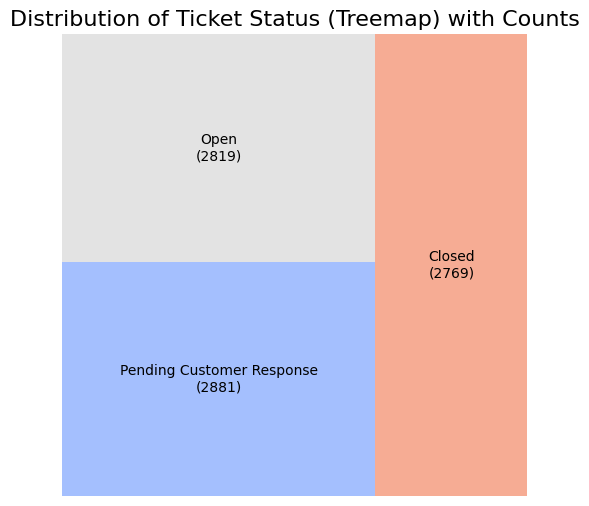

In [ ]:
import matplotlib.pyplot as plt
!pip install squarify
import squarify
ticket_status_counts = df['Ticket Status'].value_counts()
labels = [f'{status}\n({count})' for status, count in ticket_status_counts.items()]
plt.figure(figsize=(6, 6))
plt.axis('off')
squarify.plot(sizes=ticket_status_counts.values,
              label=labels,
              alpha=0.8,
              color=sns.color_palette('coolwarm', len(ticket_status_counts)))
plt.title('Distribution of Ticket Status (Treemap) with Counts', fontsize=16)
plt.show()

#### 4.Distribution of Customer Ages

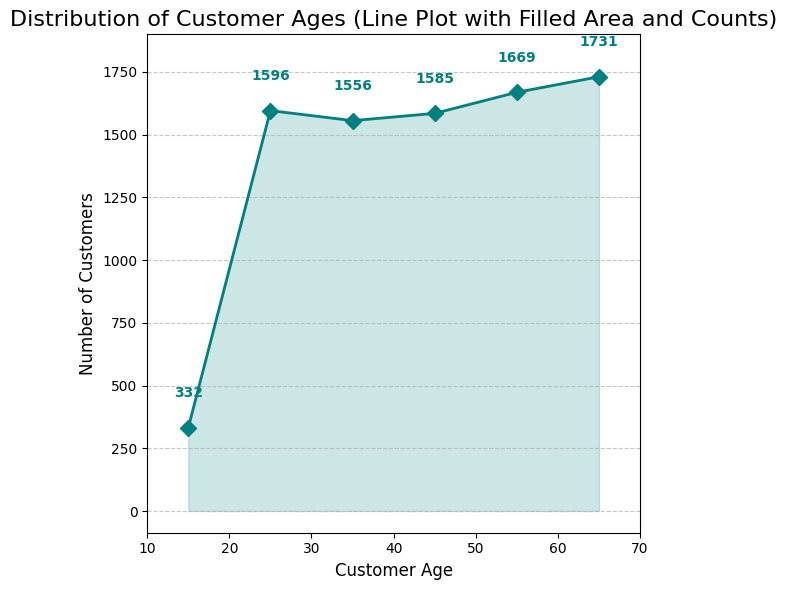

In [ ]:
import numpy as np

plt.figure(figsize=(6, 6))
age_bins = np.arange(10, df['Customer Age'].max() + 10, 10)
counts, bin_edges = np.histogram(df['Customer Age'], bins=age_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.plot(bin_centers, counts, color='teal', marker='D', linestyle='-', linewidth=2, markersize=8)
plt.fill_between(bin_centers, counts, color='teal', alpha=0.2)
plt.title('Distribution of Customer Ages (Line Plot with Filled Area and Counts)', fontsize=16)
plt.xlabel('Customer Age', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(age_bins)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(top=1900)
for x, y in zip(bin_centers, counts):
    if y > 0:
        plt.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0,20), ha='center', va='bottom', fontsize=10, color='teal', fontweight='bold')

plt.tight_layout()
plt.show()

#### 5.Average Resolution Time by Ticket Type

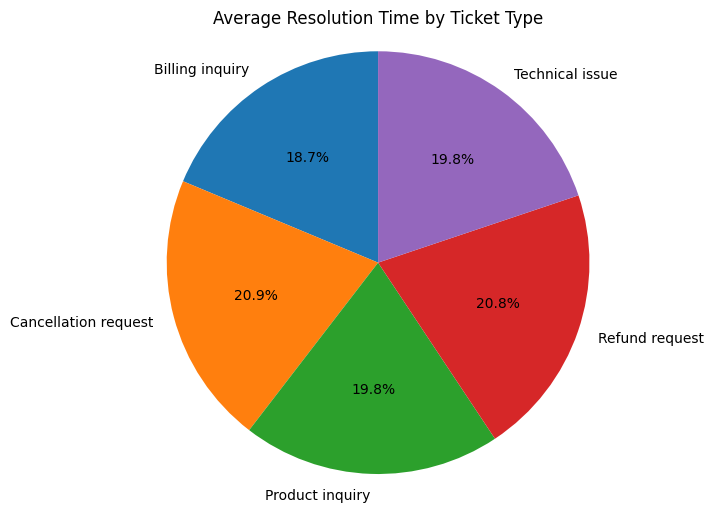

In [ ]:
import matplotlib.pyplot as plt
avg_resolution = (
    df.groupby("Ticket Type")["Resolution_Duration_Hours"]
    .mean()
    .round(2)
    .reset_index()
)
plt.figure(figsize=(6, 6))
plt.pie(avg_resolution["Resolution_Duration_Hours"],
        labels=avg_resolution["Ticket Type"],
        autopct='%1.1f%%',
        startangle=90)
plt.title("Average Resolution Time by Ticket Type")
plt.axis('equal')
plt.show()

#### 6.Customer Satisfaction Rating vs. Resolution Duration

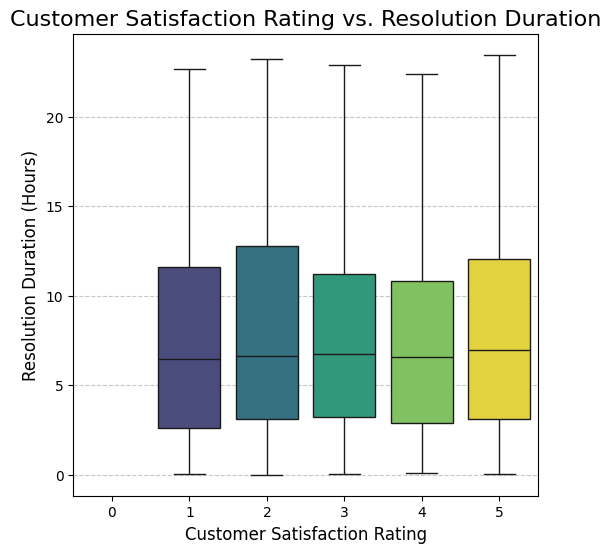

In [ ]:
plt.figure(figsize=(6, 6))
sns.boxplot(x='Customer Satisfaction Rating', y='Resolution_Duration_Hours', data=df, palette='viridis', hue='Customer Satisfaction Rating', legend=False)
plt.title('Customer Satisfaction Rating vs. Resolution Duration', fontsize=16)
plt.xlabel('Customer Satisfaction Rating', fontsize=12)
plt.ylabel('Resolution Duration (Hours)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 7.Distribution of Ticket Subjects

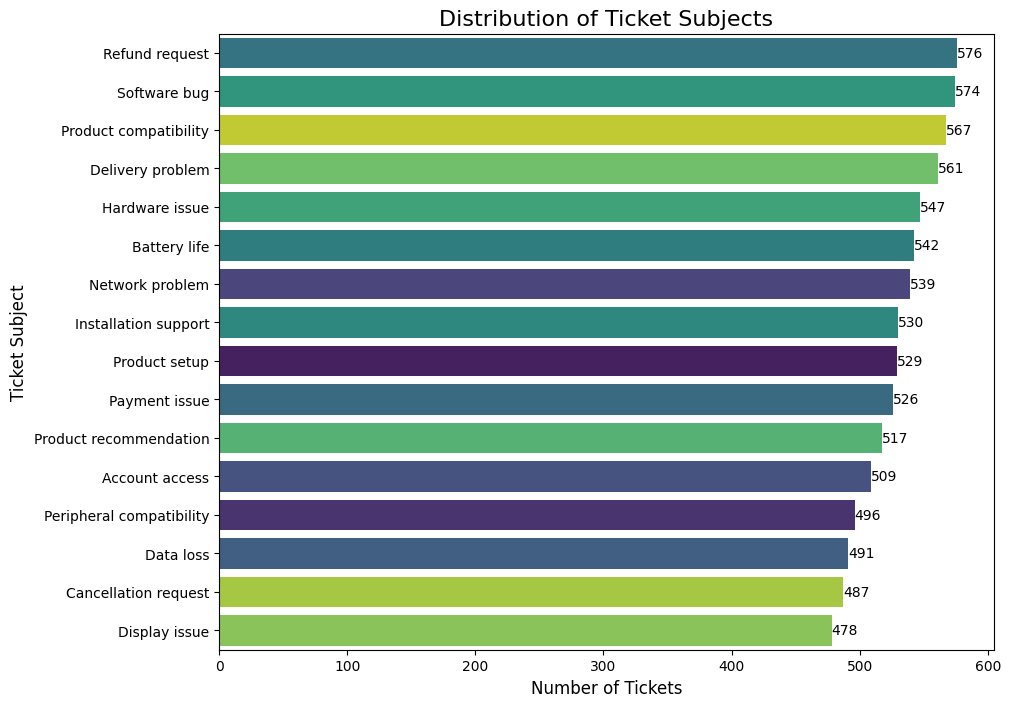

In [ ]:
plt.figure(figsize=(10, 8))
ax = sns.countplot(y='Ticket Subject', data=df, order=df['Ticket Subject'].value_counts().index, palette='viridis', hue='Ticket Subject', legend=False)
plt.title('Distribution of Ticket Subjects', fontsize=16)
plt.xlabel('Number of Tickets', fontsize=12)
plt.ylabel('Ticket Subject', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.show()

#### 8.Distribution of Top Product Purchases

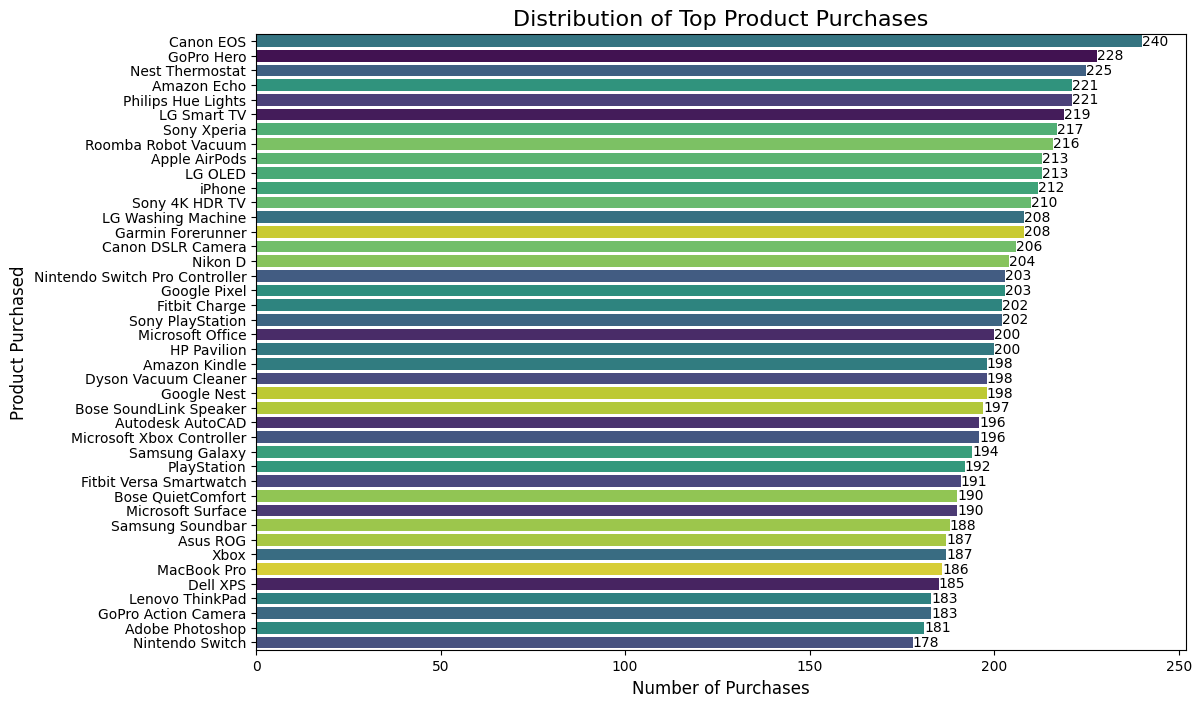

In [ ]:
plt.figure(figsize=(12, 8))
ax = sns.countplot(y='Product Purchased', data=df, order=df['Product Purchased'].value_counts().index, palette='viridis', hue='Product Purchased', legend=False)
plt.title('Distribution of Top Product Purchases', fontsize=16)
plt.xlabel('Number of Purchases', fontsize=12)
plt.ylabel('Product Purchased', fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.show()

#### 9.Customer Satisfaction Rating by Ticket Priority


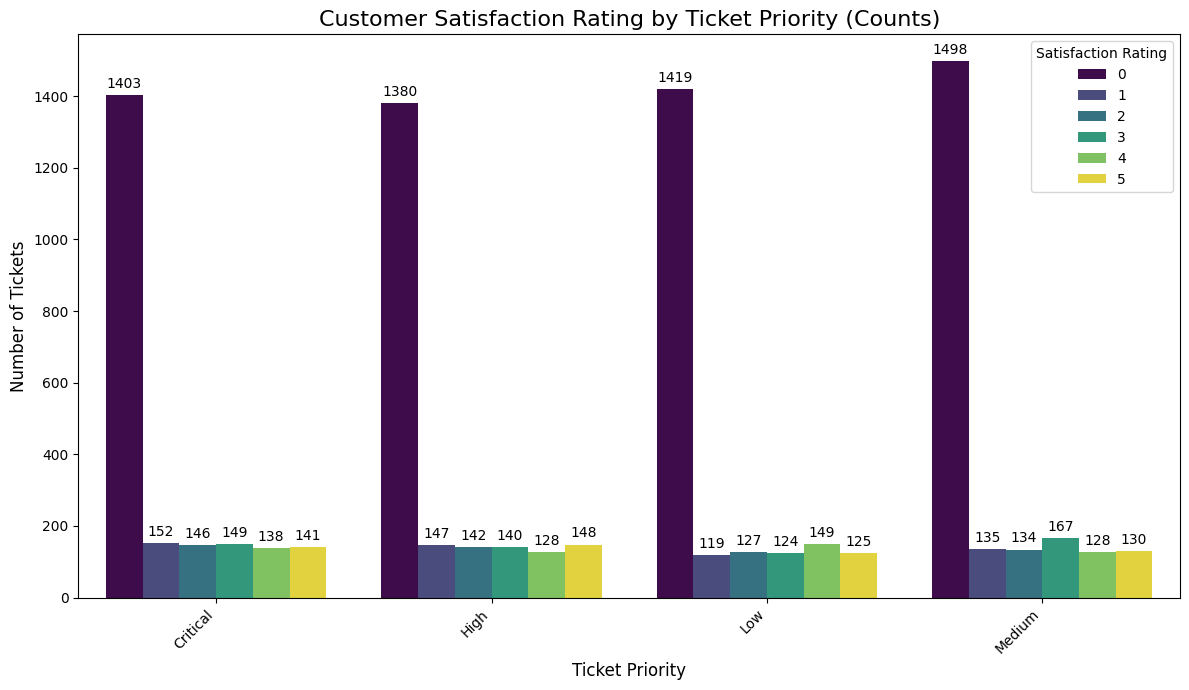

In [ ]:
satisfaction_by_priority = pd.crosstab(df["Ticket Priority"], df["Customer Satisfaction Rating"])
melted_satisfaction_by_priority = satisfaction_by_priority.reset_index().melt(
    id_vars="Ticket Priority",
    var_name="Customer Satisfaction Rating",
    value_name="Count"
)
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x="Ticket Priority",
    y="Count",
    hue="Customer Satisfaction Rating",
    data=melted_satisfaction_by_priority,
    palette="viridis"
)
plt.title("Customer Satisfaction Rating by Ticket Priority (Counts)", fontsize=16)
plt.xlabel("Ticket Priority", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Satisfaction Rating')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.tight_layout()
plt.show()

#### 10.Distribution of Product Purchased by Ticket Priority

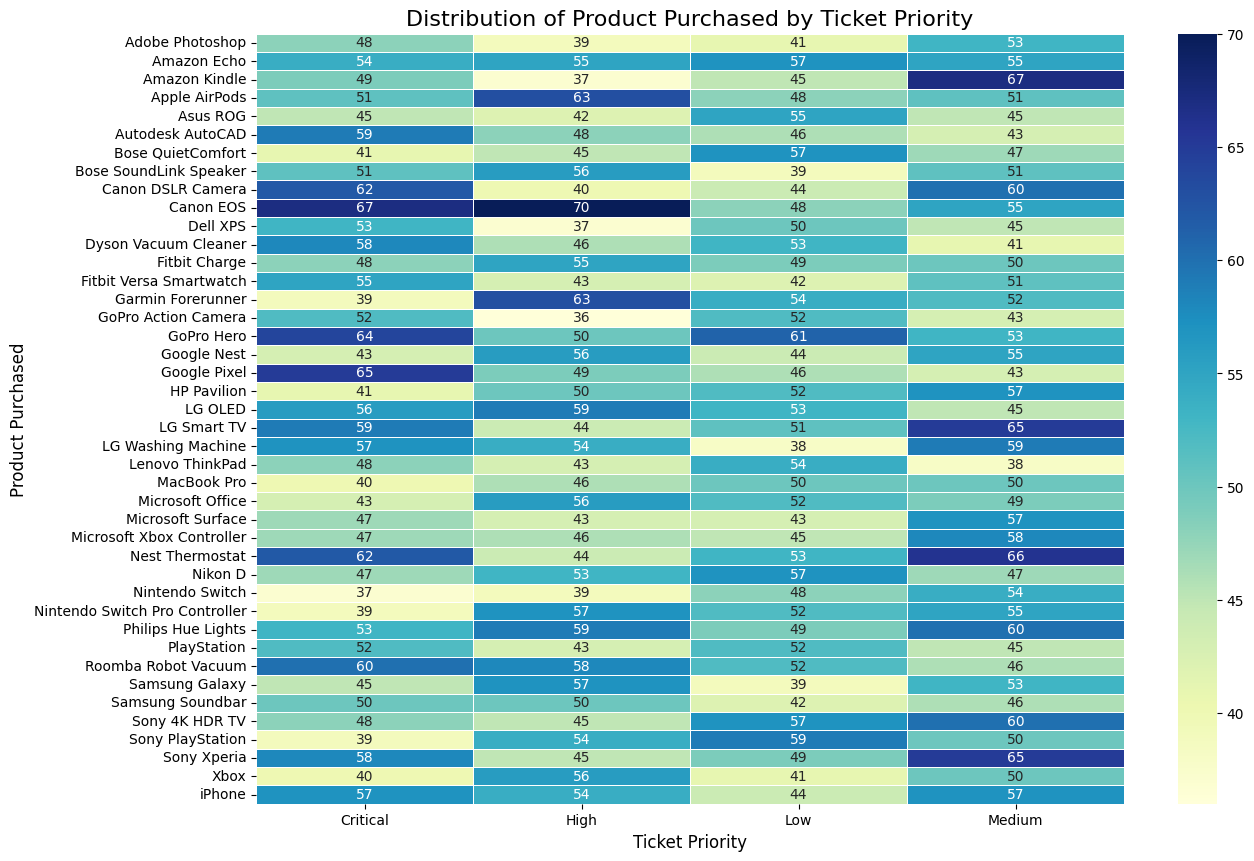

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
heatmap_data = pd.crosstab(df['Product Purchased'], df['Ticket Priority'])
plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Distribution of Product Purchased by Ticket Priority', fontsize=16)
plt.xlabel('Ticket Priority', fontsize=12)
plt.ylabel('Product Purchased', fontsize=12)
plt.show()

#### 11.Clustering of Ticket Type by Ticket Channel frequency

In [ ]:
ticket_channel_by_type = pd.crosstab(df['Ticket Channel'], df['Ticket Type'])
ticket_channel_by_type

Ticket Type,Billing inquiry,Cancellation request,Product inquiry,Refund request,Technical issue
Ticket Channel,,,,,
Chat,398,408,388,426,453
Email,405,448,427,455,408
Phone,434,426,424,427,421
Social media,397,413,402,444,465


In [ ]:
melted_ticket_channel_by_type = ticket_channel_by_type.reset_index().melt(
    id_vars='Ticket Channel',
    var_name='Ticket Type',
    value_name='Count'
)
melted_ticket_channel_by_type.head()

,Ticket Channel,Ticket Type,Count
0,Chat,Billing inquiry,398
1,Email,Billing inquiry,405
2,Phone,Billing inquiry,434
3,Social media,Billing inquiry,397
4,Chat,Cancellation request,408


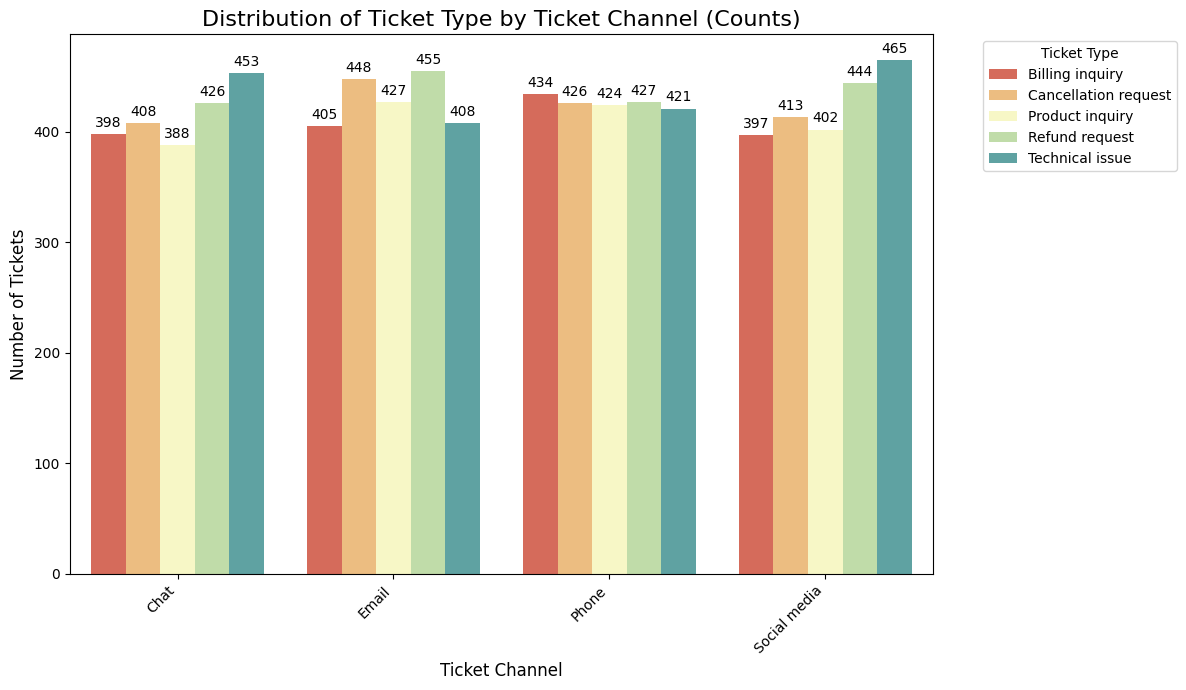

In [ ]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='Ticket Channel',
    y='Count',
    hue='Ticket Type',
    data=melted_ticket_channel_by_type,
    palette='Spectral'
)
plt.title('Distribution of Ticket Type by Ticket Channel (Counts)', fontsize=16)
plt.xlabel('Ticket Channel', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Ticket Type', bbox_to_anchor=(1.05, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Define a list of 5 countries
countries = ['USA', 'Canada', 'UK', 'Australia', 'Germany']

# Add a new 'country' column with random selections from the countries list
df['country'] = np.random.choice(countries, size=len(df))

display(df.head())

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Priority_Score,Resolution_Duration_Hours,Resolution_category,country
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT,0,4,NaN,Slow,UK
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT,0,4,NaN,Slow,USA
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3,1,6.85,Medium,Canada
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3,1,5.53,Medium,UK
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1,1,19.68,Slow,Canada


In [ ]:
df['country'].value_counts()

,count
country,
Canada,1753
Germany,1716
USA,1674
Australia,1671
UK,1655


In [ ]:
df.to_excel("data.xlsx", index=False)

In [ ]:

avg_resolution_by_country = (
    df.groupby("country")["Resolution_Duration_Hours"]
    .mean()
    .round(2)
    .reset_index()
)
print(avg_resolution_by_country)

     country  Resolution_Duration_Hours
0  Australia                       7.82
1     Canada                       8.05
2    Germany                       7.83
3         UK                       7.38
4        USA                       7.60


In [ ]:
fastest_resolution_country = avg_resolution_by_country.loc[avg_resolution_by_country['Resolution_Duration_Hours'].idxmin()]
print("Country with the fastest resolution time:")
print(fastest_resolution_country)

Country with the fastest resolution time:
country                        UK
Resolution_Duration_Hours    7.38
Name: 3, dtype: object


/tmp/ipykernel_646/46166435.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='Resolution_Duration_Hours', data=avg_resolution_by_country, palette='viridis')


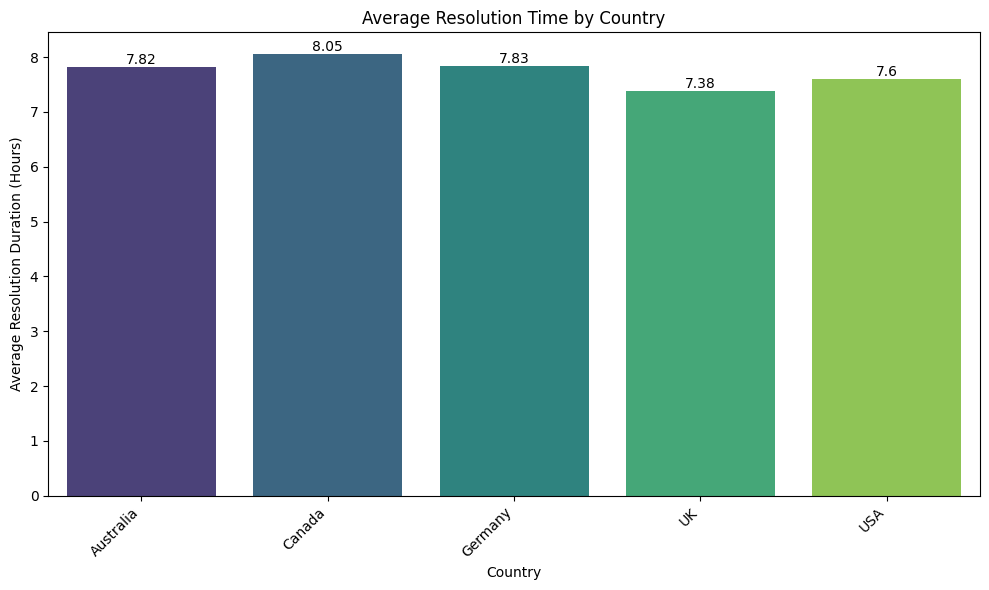

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='country', y='Resolution_Duration_Hours', data=avg_resolution_by_country, palette='viridis')
plt.title('Average Resolution Time by Country')
plt.xlabel('Country')
plt.ylabel('Average Resolution Duration (Hours)')
plt.xticks(rotation=45, ha='right')
for index, row in avg_resolution_by_country.iterrows():
    plt.text(row.name, row.Resolution_Duration_Hours, round(row.Resolution_Duration_Hours, 2), color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

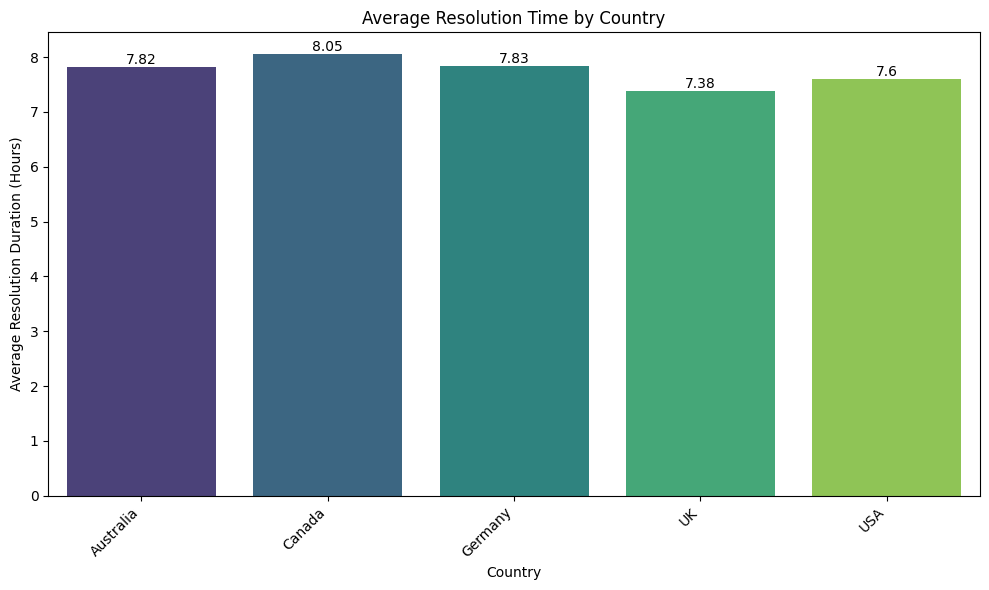

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='country', y='Resolution_Duration_Hours', data=avg_resolution_by_country, palette='viridis', hue='country', legend=False)
plt.title('Average Resolution Time by Country')
plt.xlabel('Country')
plt.ylabel('Average Resolution Duration (Hours)')
plt.xticks(rotation=45, ha='right')
for index, row in avg_resolution_by_country.iterrows():
    plt.text(row.name, row.Resolution_Duration_Hours, round(row.Resolution_Duration_Hours, 2), color='black', ha="center", va='bottom')
plt.tight_layout()
plt.show()

In [ ]:
avg_resolution_by_priority_type = df.groupby(['Ticket Priority', 'Ticket Type'])['Resolution_Duration_Hours'].mean().unstack().round(2)
display(avg_resolution_by_priority_type)

Ticket Type,Billing inquiry,Cancellation request,Product inquiry,Refund request,Technical issue
Ticket Priority,,,,,
Critical,6.97,8.62,7.88,7.18,7.17
High,7.87,7.81,7.70,9.11,8.30
Low,6.88,8.52,7.62,7.98,8.36
Medium,7.27,7.39,7.37,7.90,6.83


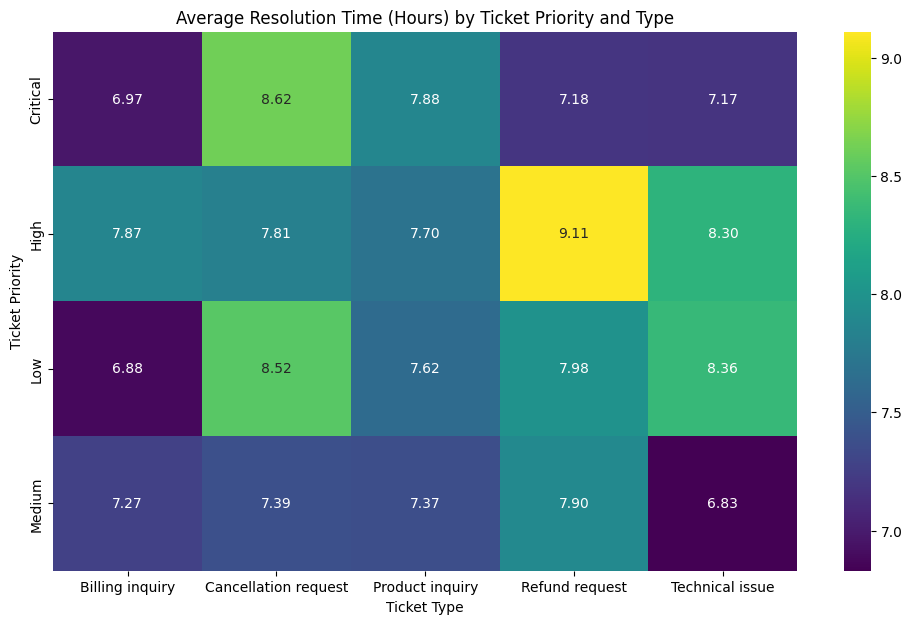

In [ ]:
plt.figure(figsize=(12, 7))
sns.heatmap(avg_resolution_by_priority_type, annot=True, fmt=".2f", cmap="viridis")
plt.title('Average Resolution Time (Hours) by Ticket Priority and Type')
plt.xlabel('Ticket Type')
plt.ylabel('Ticket Priority')
plt.show()